
# Bank Marketing Campaign Analysis

## 1. Project Overview

### Objective
Analyze bank marketing campaign data to understand customer subscription patterns and identify factors associated with term deposit subscriptions.

### Dataset
Bank Marketing dataset from the UCI Machine Learning Repository.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [8]:

data_path = Path(
    r"D:\Bank Marketing Campaign Analysis\data\raw\bank+marketing\bank-additional\bank-additional\bank-additional-full.csv"
)

df = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully!")
print("Number of rows and columns:", df.shape)

df.head()


Dataset loaded successfully!
Number of rows and columns: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 41188
Number of columns: 21


In [10]:

print("Dataset columns:\n")

for column in df.columns:
    print(column)


Dataset columns:

age
job
marital
education
default
housing
loan
contact
month
day_of_week
duration
campaign
pdays
previous
poutcome
emp.var.rate
cons.price.idx
cons.conf.idx
euribor3m
nr.employed
y


In [11]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [12]:

print("Missing values in each column:\n")
print(df.isnull().sum())


Missing values in each column:

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [13]:

print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 12


In [14]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:

print("Subscription counts:")
print(df["y"].value_counts())

print("\nSubscription percentages:")
print((df["y"].value_counts(normalize=True) * 100).round(2))


Subscription counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Subscription percentages:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


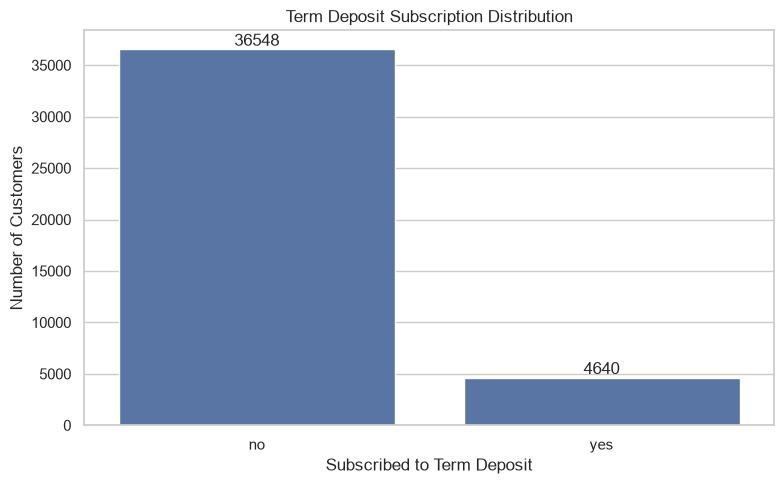

In [16]:

subscription_counts = df["y"].value_counts().reindex(["no", "yes"])

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=subscription_counts.index,
    y=subscription_counts.values
)

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()



### Observation — Target Variable

The target variable `y` indicates whether a customer subscribed to a term deposit.

The subscription counts and percentages show the balance between successful and unsuccessful campaign outcomes. This distribution will help us understand whether the dataset is imbalanced and why overall customer response rate matters when evaluating campaign performance.


In [17]:

job_subscription = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
    .reset_index(name="subscription_rate")
)

job_subscription


,job,subscription_rate
0,student,31.43
1,retired,25.23
2,unemployed,14.20
3,admin.,12.97
4,management,11.22
5,unknown,11.21
6,technician,10.83
7,self-employed,10.49
8,housemaid,10.00
9,entrepreneur,8.52


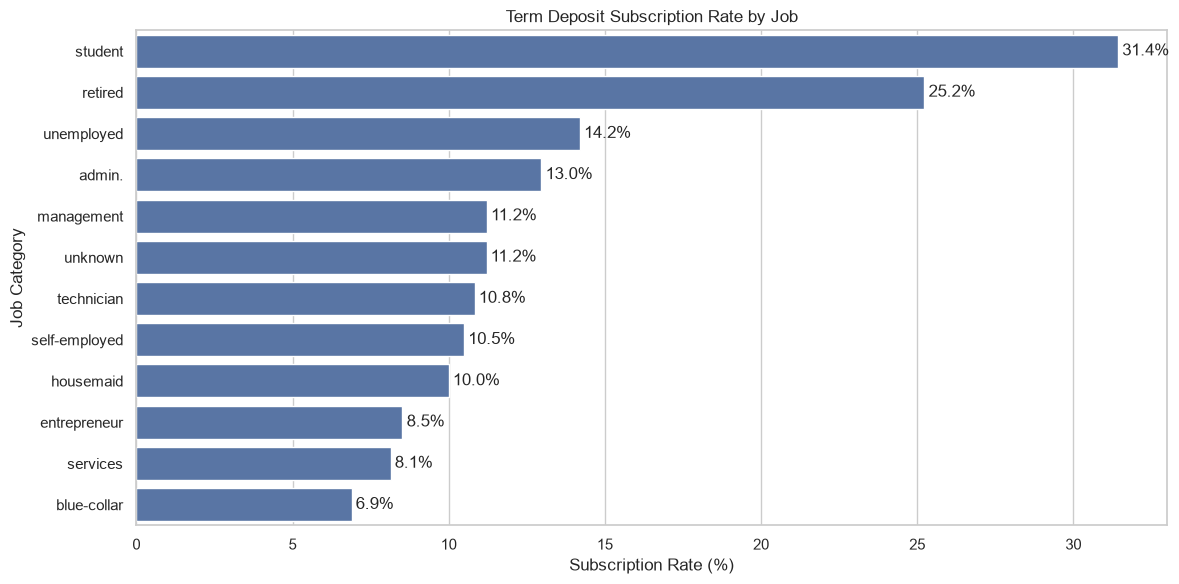

In [18]:

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=job_subscription,
    x="subscription_rate",
    y="job"
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()



### Observation — Subscription Rate by Job

The subscription rate differs across job categories. This analysis helps identify which customer groups showed stronger responses to the bank's marketing campaign.

A higher subscription rate indicates a higher proportion of customers subscribed within that job category. However, it does not necessarily mean that category produced the largest number of subscriptions.


In [19]:

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18–25", "26–35", "36–45", "46–55", "56–65", "65+"],
    include_lowest=True
)

age_subscription = (
    df.groupby("age_group", observed=False)["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="subscription_rate")
)

age_subscription


,age_group,subscription_rate
0,18–25,20.948379
1,26–35,11.719539
2,36–45,8.509810
3,46–55,8.691963
4,56–65,15.221060
5,65+,46.849758


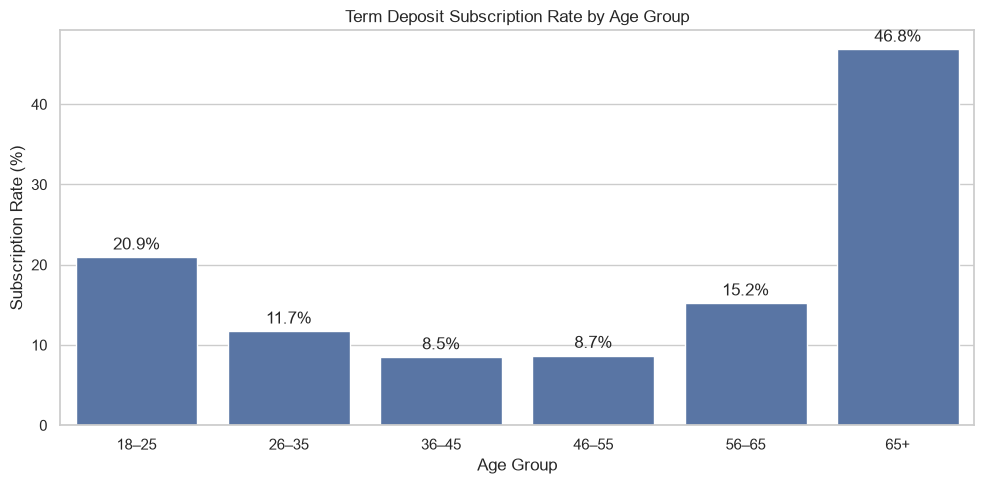

In [20]:

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=age_subscription,
    x="age_group",
    y="subscription_rate"
)

plt.title("Term Deposit Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()



### Observation — Subscription Rate by Age

Subscription rates vary across age groups. Comparing response percentages helps identify age groups that were more receptive to the bank's campaign.

These results describe associations in the dataset and do not establish that age causes a customer to subscribe.


In [21]:

contact_subscription = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .round(2)
    .reset_index(name="subscription_rate")
)

contact_subscription


,contact,subscription_rate
0,cellular,14.74
1,telephone,5.23


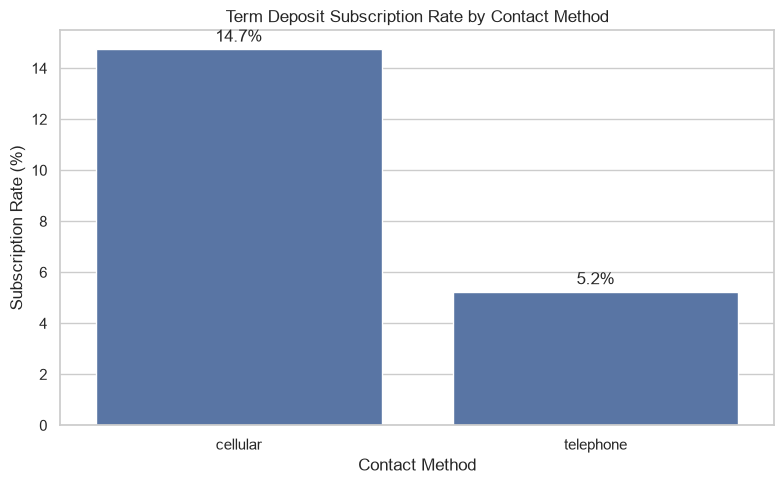

In [22]:

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contact_subscription,
    x="contact",
    y="subscription_rate"
)

plt.title("Term Deposit Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


In [23]:

previous_outcome_subscription = (
    df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .round(2)
    .reset_index(name="subscription_rate")
    .sort_values("subscription_rate", ascending=False)
)

previous_outcome_subscription


,poutcome,subscription_rate
2,success,65.11
0,failure,14.23
1,nonexistent,8.83


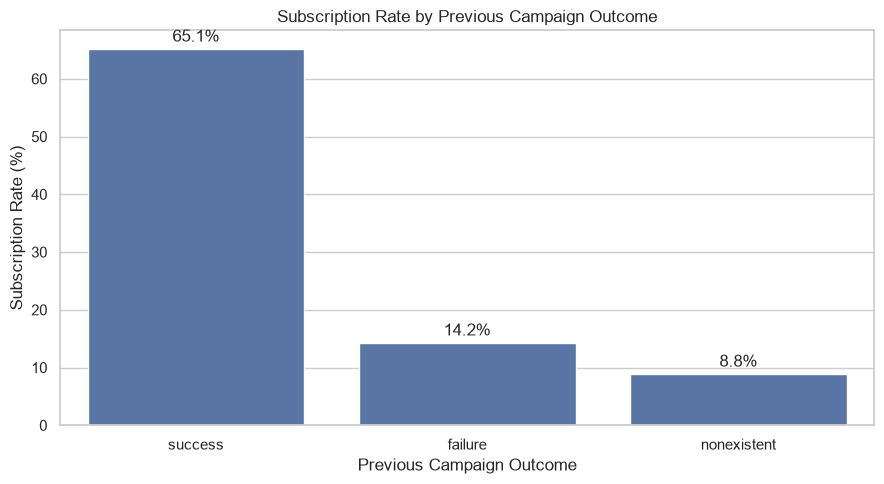

In [24]:

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=previous_outcome_subscription,
    x="poutcome",
    y="subscription_rate"
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()



## Observations — Contact Method and Previous Campaign

- Subscription rates may differ between cellular and telephone contact methods.
- Previous campaign outcomes may be associated with different subscription rates.
- These comparisons describe patterns in the observed data and do not prove that the contact method or previous outcome caused a subscription.


In [25]:

campaign_subscription = (
    df.groupby("campaign")["y"]
    .agg(
        total_customers="count",
        subscriptions=lambda x: (x == "yes").sum()
    )
    .reset_index()
)

campaign_subscription["subscription_rate"] = (
    campaign_subscription["subscriptions"]
    / campaign_subscription["total_customers"] * 100
).round(2)

campaign_subscription.head(15)


,campaign,total_customers,subscriptions,subscription_rate
0,1,17642,2300,13.04
1,2,10570,1211,11.46
2,3,5341,574,10.75
3,4,2651,249,9.39
4,5,1599,120,7.50
5,6,979,75,7.66
6,7,629,38,6.04
7,8,400,17,4.25
8,9,283,17,6.01
9,10,225,12,5.33


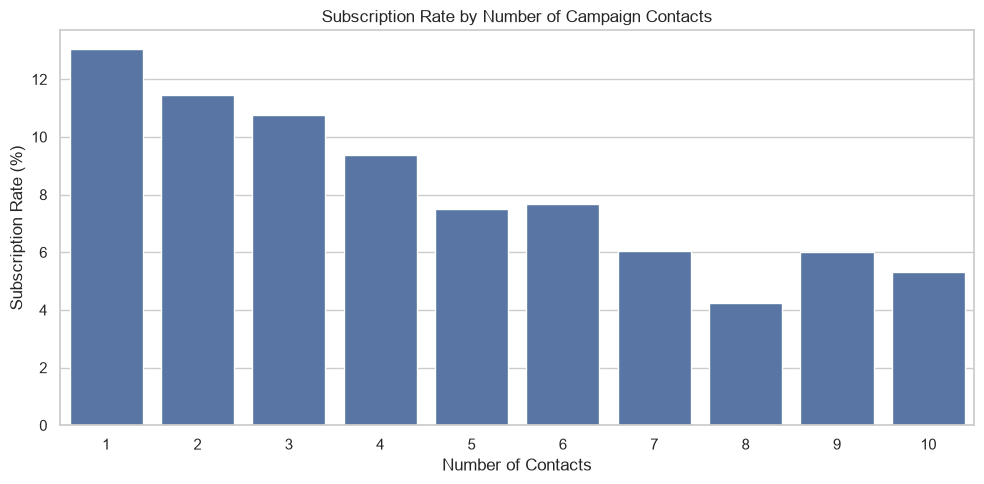

In [26]:

plot_data = campaign_subscription[
    campaign_subscription["campaign"] <= 10
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=plot_data,
    x="campaign",
    y="subscription_rate"
)

plt.title("Subscription Rate by Number of Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()
plt.show()


In [27]:

print("Actual missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nUnknown values by column:")
unknown_counts = (
    df.astype("string")
    .eq("unknown")
    .sum()
    .sort_values(ascending=False)
)

print(unknown_counts[unknown_counts > 0])


Actual missing values:
age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
dtype: int64

Unknown values by column:
default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: Int64



## Observations — Campaign Frequency and Data Quality

- Subscription rates can vary with the number of contacts made during the campaign.
- Repeated contact does not automatically imply a higher subscription rate.
- The dataset may contain values labelled `unknown`, which should be considered when interpreting categorical variables.
- Actual missing values and unknown categories are different and should be assessed separately before data cleaning.


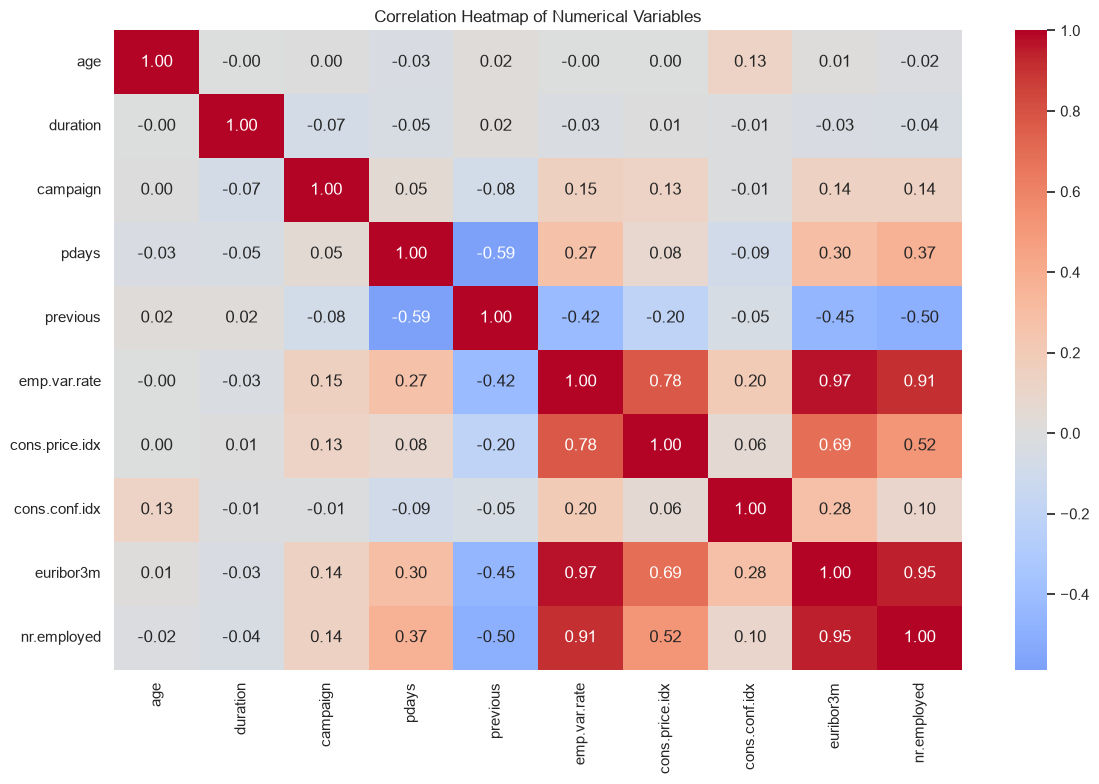

In [28]:

numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()


In [29]:

month_order = [
    "mar", "apr", "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

month_subscription = (
    df.groupby("month", observed=False)["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reindex(month_order)
    .dropna()
    .reset_index(name="subscription_rate")
)

month_subscription


,month,subscription_rate
0,mar,50.549451
1,apr,20.478723
2,may,6.434745
3,jun,10.511470
4,jul,9.046557
5,aug,10.602137
6,sep,44.912281
7,oct,43.871866
8,nov,10.143867
9,dec,48.901099


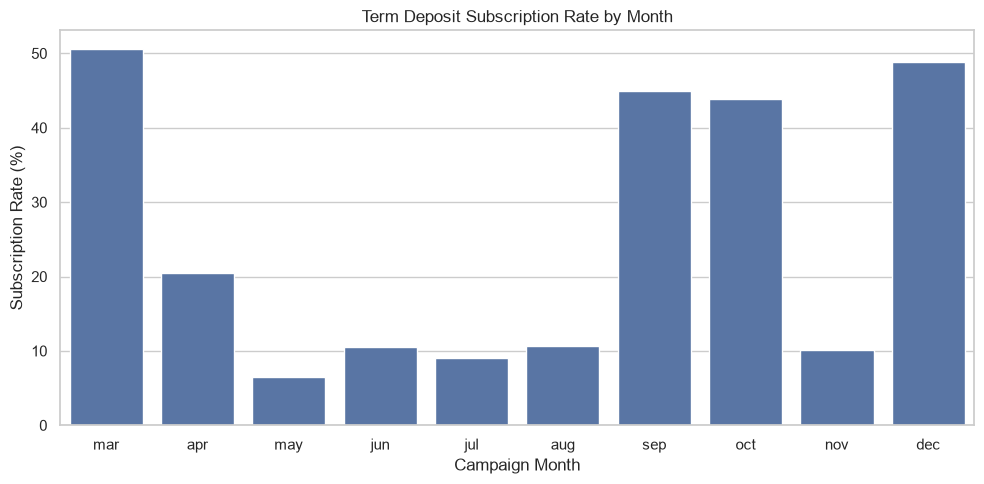

In [30]:

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=month_subscription,
    x="month",
    y="subscription_rate",
    order=month_order
)

plt.title("Term Deposit Subscription Rate by Month")
plt.xlabel("Campaign Month")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()
plt.show()


In [31]:

overall_rate = (df["y"] == "yes").mean() * 100

print(f"Total customers: {len(df):,}")
print(f"Total subscriptions: {(df['y'] == 'yes').sum():,}")
print(f"Overall subscription rate: {overall_rate:.2f}%")

print("\nHighest subscription rate by job:")
print(job_subscription.head(3))

print("\nHighest subscription rate by age group:")
print(age_subscription.sort_values(
    "subscription_rate", ascending=False
).head(3))

print("\nSubscription rate by contact method:")
print(contact_subscription)

print("\nSubscription rate by previous campaign outcome:")
print(previous_outcome_subscription)

print("\nSubscription rate by month:")
print(month_subscription.sort_values(
    "subscription_rate", ascending=False
).head(3))


Total customers: 41,188
Total subscriptions: 4,640
Overall subscription rate: 11.27%

Highest subscription rate by job:
          job  subscription_rate
0     student              31.43
1     retired              25.23
2  unemployed              14.20

Highest subscription rate by age group:
  age_group  subscription_rate
5       65+          46.849758
0     18–25          20.948379
4     56–65          15.221060

Subscription rate by contact method:
     contact  subscription_rate
0   cellular              14.74
1  telephone               5.23

Subscription rate by previous campaign outcome:
      poutcome  subscription_rate
2      success              65.11
0      failure              14.23
1  nonexistent               8.83

Subscription rate by month:
  month  subscription_rate
0   mar          50.549451
9   dec          48.901099
6   sep          44.912281



# 10. Conclusion

This exploratory data analysis examined customer characteristics,
marketing campaign activity, contact methods, previous campaign outcomes,
and economic indicators associated with term deposit subscriptions.

The analysis compares subscription rates across customer groups and
campaign conditions to identify patterns that may help improve campaign
planning.

The findings are descriptive and show associations in the observed data;
they do not establish causation. Further evaluation would be needed before
using these patterns to guide future campaigns.


In [33]:

from pathlib import Path
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
)

project_dir = Path(r"D:\Bank Marketing Campaign Analysis")
report_dir = project_dir / "report"
report_dir.mkdir(parents=True, exist_ok=True)

pdf_path = report_dir / "Bank_Marketing_EDA_Report.pdf"

styles = getSampleStyleSheet()
story = []

yes_count = int((df["y"] == "yes").sum())
no_count = int((df["y"] == "no").sum())
overall_rate = (df["y"] == "yes").mean() * 100

story.append(Paragraph(
    "Bank Marketing Campaign Analysis",
    styles["Title"]
))
story.append(Spacer(1, 12))
story.append(Paragraph("Exploratory Data Analysis Report", styles["Heading2"]))
story.append(Spacer(1, 16))

story.append(Paragraph("1. Project Objective", styles["Heading1"]))
story.append(Paragraph(
    "Analyze customer and campaign data to identify patterns associated "
    "with term deposit subscriptions.",
    styles["BodyText"]
))
story.append(Spacer(1, 12))

story.append(Paragraph("2. Dataset Overview", styles["Heading1"]))

summary_data = [
    ["Metric", "Value"],
    ["Total records", f"{len(df):,}"],
    ["Total columns", str(df.shape[1])],
    ["Subscribed (yes)", f"{yes_count:,}"],
    ["Not subscribed (no)", f"{no_count:,}"],
    ["Subscription rate", f"{overall_rate:.2f}%"],
]

table = Table(summary_data, colWidths=[3 * inch, 2 * inch])
table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#243B53")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("PADDING", (0, 0), (-1, -1), 7),
]))
story.append(table)
story.append(Spacer(1, 12))

story.append(Paragraph("3. Analysis Performed", styles["Heading1"]))
for item in [
    "Dataset structure and descriptive statistics",
    "Subscription distribution",
    "Subscription rates by job and age group",
    "Subscription rates by contact method and previous outcome",
    "Campaign frequency and monthly subscription rates",
    "Numerical correlation analysis",
    "Missing values, unknown categories, and duplicate checks",
]:
    story.append(Paragraph(f"- {item}", styles["BodyText"]))
    story.append(Spacer(1, 4))

story.append(Paragraph("4. Interpretation and Limitations", styles["Heading1"]))
story.append(Paragraph(
    "The results describe associations in the observed data and do not "
    "establish causation. The duration variable measures the length of the "
    "last call and should not be used to select customers before a call.",
    styles["BodyText"]
))
story.append(Spacer(1, 12))

story.append(Paragraph("5. Conclusion", styles["Heading1"]))
story.append(Paragraph(
    "This exploratory analysis summarizes customer subscription patterns "
    "and campaign characteristics. Further evaluation is needed before "
    "using these findings to guide future campaigns.",
    styles["BodyText"]
))

doc = SimpleDocTemplate(
    str(pdf_path),
    pagesize=A4,
    rightMargin=0.65 * inch,
    leftMargin=0.65 * inch,
    topMargin=0.65 * inch,
    bottomMargin=0.65 * inch
)

doc.build(story)

print("PDF created successfully!")
print("Saved to:", pdf_path)
print("File exists:", pdf_path.exists())


PDF created successfully!
Saved to: D:\Bank Marketing Campaign Analysis\report\Bank_Marketing_EDA_Report.pdf
File exists: True


In [34]:
%pip install python-pptx

  Using cached python_pptx-1.0.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached xlsxwriter-3.2.9-py3-none-any.whl.metadata (2.7 kB)
  Using cached lxml-6.1.3-cp311-cp311-win_amd64.whl.metadata (3.4 kB)
Using cached python_pptx-1.0.2-py3-none-any.whl (472 kB)
Using cached lxml-6.1.3-cp311-cp311-win_amd64.whl (4.0 MB)
Using cached xlsxwriter-3.2.9-py3-none-any.whl (175 kB)

   ---------------------------------------- 0/3 [XlsxWriter]
   ---------------------------------------- 0/3 [XlsxWriter]
   ---------------------------------------- 0/3 [XlsxWriter]
   ---------------------------------------- 0/3 [XlsxWriter]
   ---------------------------------------- 0/3 [XlsxWriter]
   ---------------------------------------- 0/3 [XlsxWriter]
   ---------------------------------------- 0/3 [XlsxWriter]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------

In [35]:

from pathlib import Path
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN

project_dir = Path(r"D:\Bank Marketing Campaign Analysis")
presentation_dir = project_dir / "presentation"
presentation_dir.mkdir(parents=True, exist_ok=True)

ppt_path = presentation_dir / "Bank_Marketing_Analysis.pptx"

prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

NAVY = RGBColor(31, 50, 78)
BLUE = RGBColor(55, 105, 160)
WHITE = RGBColor(255, 255, 255)
DARK = RGBColor(45, 45, 45)

def add_slide(title, bullets, subtitle=None):
    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Header background
    shape = slide.shapes.add_shape(
        1, Inches(0), Inches(0), Inches(13.333), Inches(1.25)
    )
    shape.fill.solid()
    shape.fill.fore_color.rgb = NAVY
    shape.line.fill.background()

    title_box = slide.shapes.add_textbox(
        Inches(0.55), Inches(0.25), Inches(12.2), Inches(0.7)
    )
    p = title_box.text_frame.paragraphs[0]
    p.text = title
    p.font.size = Pt(27)
    p.font.bold = True
    p.font.color.rgb = WHITE

    if subtitle:
        sub_box = slide.shapes.add_textbox(
            Inches(0.7), Inches(1.55), Inches(12), Inches(0.6)
        )
        p = sub_box.text_frame.paragraphs[0]
        p.text = subtitle
        p.font.size = Pt(16)
        p.font.color.rgb = BLUE

    body = slide.shapes.add_textbox(
        Inches(0.8), Inches(2.1 if subtitle else 1.8),
        Inches(11.8), Inches(4.8)
    )
    tf = body.text_frame
    tf.word_wrap = True

    for i, bullet in enumerate(bullets):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.text = bullet
        p.level = 0
        p.font.size = Pt(21)
        p.font.color.rgb = DARK
        p.space_after = Pt(18)

    # Footer
    footer = slide.shapes.add_textbox(
        Inches(0.6), Inches(7.1), Inches(12), Inches(0.2)
    )
    p = footer.text_frame.paragraphs[0]
    p.text = "Bank Marketing Campaign Analysis  |  Exploratory Data Analysis"
    p.font.size = Pt(9)
    p.font.color.rgb = BLUE

    return slide

# 1. Title
add_slide(
    "Bank Marketing Campaign Analysis",
    [
        "Exploratory Data Analysis (EDA)",
        "Understanding customer term deposit subscriptions",
        "Tools: Python, Pandas, Matplotlib, Seaborn and Jupyter Notebook",
    ],
    "Project Presentation"
)

# 2. Objective
add_slide(
    "Project Objective",
    [
        "Explore customer demographics and marketing campaign information.",
        "Measure subscription rates across customer groups.",
        "Compare contact methods, previous campaign outcomes and campaign timing.",
        "Identify patterns that may support better campaign planning.",
    ]
)

# 3. Dataset
add_slide(
    "Dataset Overview",
    [
        f"Records: {len(df):,}",
        f"Variables: {df.shape[1]}",
        f"Subscriptions: {(df['y'] == 'yes').sum():,}",
        f"Non-subscriptions: {(df['y'] == 'no').sum():,}",
        f"Overall subscription rate: {(df['y'] == 'yes').mean() * 100:.2f}%",
        "Source: UCI Machine Learning Repository — Bank Marketing dataset",
    ]
)

# 4. Analysis
add_slide(
    "Exploratory Analysis",
    [
        "Reviewed dataset structure, data types and descriptive statistics.",
        "Checked actual missing values, unknown categories and duplicate rows.",
        "Compared subscription rates by job category and age group.",
        "Examined contact method, previous campaign outcome and campaign month.",
    ]
)

# 5. Campaign patterns
add_slide(
    "Campaign Response Patterns",
    [
        "Subscription rates can differ across customer groups.",
        "Previous campaign outcomes may be associated with current responses.",
        "Contact frequency should be assessed using both customer counts and rates.",
        "Monthly response rates can vary with campaign volume and timing.",
    ]
)

# 6. Limitations
add_slide(
    "Limitations and Considerations",
    [
        "The analysis describes associations; it does not prove causation.",
        "Unknown categories may affect interpretation of customer characteristics.",
        "Campaign results may depend on the historical period and economic context.",
        "Call duration is known after the call and should not be used for pre-call targeting.",
    ]
)

# 7. Conclusion
add_slide(
    "Conclusion and Recommendations",
    [
        "Use subscription rates alongside customer counts to compare segments.",
        "Review campaign outcomes and contact frequency before changing strategy.",
        "Validate findings on newer data before applying them to current campaigns.",
        "Further analysis could evaluate customer targeting and campaign effectiveness.",
    ]
)

prs.save(ppt_path)

print("Presentation created successfully!")
print("Slides:", len(prs.slides))
print("Saved to:", ppt_path)


Presentation created successfully!
Slides: 7
Saved to: D:\Bank Marketing Campaign Analysis\presentation\Bank_Marketing_Analysis.pptx


In [ ]:

from pathlib import Path

project_dir = Path(r"D:\Bank Marketing Campaign Analysis")

files_to_check = [
    project_dir / "notebooks" / "Bank_Marketing_EDA.ipynb",
    project_dir / "README.md",
    project_dir / "report" / "Bank_Marketing_EDA_Report.pdf",
    project_dir / "presentation" / "Bank_Marketing_Analysis.pptx",
]

for file in files_to_check:
    status = "FOUND" if file.exists() else "MISSING"
    print(f"{status}: {file.relative_to(project_dir)}")
